# Evaluation: Amplification

## Setup


In [1]:
# Hack for import from another directory
from pathlib import Path
import sys

poc_path = str(Path().resolve().parent)
if poc_path not in sys.path:
    sys.path.append(poc_path)

In [2]:
from collections.abc import Callable
from itertools import product
from pathlib import Path
from pickle import dump, load
from random import Random
from statistics import mean, stdev
from typing import Any, Iterable

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from compressors.interface import *
from crime_automata import dictionary, filler, utils
from crime_automata.gadgets import PlaceholderGadget
from crime_automata.deflate import automata, params
from crime_automata.deflate.collisions import DeflateInstanceSet
from crime_automata.deflate.gadgets import *
from crime_automata.randbytes import RandBytes
from crime_automata.strategies.models import CRIMEChainModel, CRIMECascadeModel
from crime_automata.strategies.oracle import TestCompressionLengthOracle, Placeholder
from crime_automata.strategies.matchbuilder import DefaultMatchBuilder

In [3]:
TEST_MODE = False
ATTACK_RNG_SEED = b"attack_test" if TEST_MODE else b"attack"
EVAL_RNG_SEED = b"eval_test" if TEST_MODE else b"eval"
DEMO_RNG = Random(b"demo")

NUM_EVALS = 1000

RESULTS_DIR = "results_ampl/"

In [4]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

In [5]:
def save_results(results: Any, filename: str) -> None:
    with open(Path(RESULTS_DIR, filename), "wb") as f:
        dump(results, f)


def load_results(filename: str) -> Any:
    with open(Path(RESULTS_DIR, filename), "rb") as f:
        return load(f)

In [6]:
def diff(ls_a: Iterable[int], ls_b: Iterable[int]) -> list[int]:
    return [a - b for a, b in zip(ls_a, ls_b)]

In [7]:
def evaluate(
    experiment: Callable[[Random, Random], tuple[int, ...] | None],
    n: int,
    attack_rng: Random | None = None,
    eval_rng: Random | None = None,
    salt: bytes = b"",
    strict: bool = True,
) -> list:
    if attack_rng is None:
        attack_rng = Random(ATTACK_RNG_SEED + salt)
    if eval_rng is None:
        eval_rng = Random(EVAL_RNG_SEED + salt)

    results: list = []

    for _ in range(n):
        while True:
            res = experiment(attack_rng, eval_rng)
            if res is not None:
                results.append(res)
                break
            else:
                assert not strict, "experiment failed"

    return list(zip(*results))


demo_exp = lambda a_rng, e_rng: (a_rng.randrange(10), e_rng.randrange(10))
evaluate(demo_exp, n=5), evaluate(demo_exp, n=5), evaluate(demo_exp, n=5, salt=b"/demo")

([(0, 5, 1, 5, 5), (1, 2, 8, 8, 7)],
 [(0, 5, 1, 5, 5), (1, 2, 8, 8, 7)],
 [(8, 9, 7, 8, 8), (3, 0, 4, 1, 6)])

In [8]:
def report_stats(result: Iterable[int]) -> dict[str, int | float]:
    # Note that Bessel's correction is applied for the sample standard deviation
    return {
        "min": min(result),
        "max": max(result),
        "mean": mean(result),
        "stdev": stdev(result),
    }


def report_ampl_expt_stats(
    query_lens: Iterable[int],
    data_right: Iterable[int],
    data_wrong: Iterable[int],
    reverse_diff: bool = False,
) -> dict[str, dict[str, int | float]]:
    comp_diff_lens = (
        diff(data_right, data_wrong) if reverse_diff else diff(data_wrong, data_right)
    )
    ampl_ratios = [y / x for x, y in zip(query_lens, comp_diff_lens)]
    return {
        "n": len(query_lens),
        "query": report_stats(query_lens),
        "comp_diff": report_stats(comp_diff_lens),
        "ratio": report_stats(ampl_ratios),
    }


report_stats(diff(*evaluate(demo_exp, n=10))), report_stats(
    diff(*evaluate(demo_exp, n=1000))
)

({'min': -7, 'max': 3, 'mean': -0.8, 'stdev': 3.2591750830880843},
 {'min': -9, 'max': 9, 'mean': -0.081, 'stdev': 3.9598130156762603})

In [9]:
def unif_noise_len_closure(lb: int, ub: int) -> int:
    return lambda rng: rng.randint(lb, ub)


def unif_pad_len_closure(lb: int, ub: int) -> int:
    return lambda _, rng: rng.randint(lb, ub)


[unif_noise_len_closure(0, 5)(DEMO_RNG) for _ in range(10)]

[5, 3, 2, 4, 4, 0, 0, 0, 5, 4]

In [10]:
# `[k1 filler bytes][prefix][secret][k2 filler bytes][query][k3 filler bytes][optional noise]`
def amplify_expt_closure(
    model: CRIMEChainModel,
    compress: Callable[[Any], bytes],
    filler_sizes: tuple[int, int, int] = (500, 500, 500),
    filler_charset: bytes = utils.ASCII_PRINTABLE_BYTES,
    prefix_size: int = 8,
    prefix_charset: bytes = utils.ALPHANUMERIC_BYTES,
    secret_size: int = 1,
    secret_charset: bytes = utils.ALPHANUMERIC_BYTES,
    noise_size: int = 0,
    noise_charset: bytes = utils.ALL_BYTES,
    pad_size: int = 0,
) -> Callable[[Random, Random], tuple[int, ...] | None]:

    def amplify_expt(
        attack_rng: Random, eval_rng: Random
    ) -> tuple[int, int, int] | None:
        fillers = [
            RandBytes(filler_charset, eval_rng).randbytes(filler_sizes[i])
            for i in range(3)
        ]
        prefix = RandBytes(prefix_charset, eval_rng).randbytes(prefix_size)
        secret = RandBytes(secret_charset, eval_rng).randbytes(secret_size)
        guess_right, guess_wrong = secret, secret
        while guess_wrong == secret:
            guess_wrong = RandBytes(secret_charset, eval_rng).randbytes(secret_size)
        template = [
            fillers[0],
            prefix,
            Placeholder.SECRET,
            Placeholder.NOISE,
            fillers[1],
            Placeholder.QUERY,
            fillers[2],
        ]
        oracle = TestCompressionLengthOracle(
            template=template,
            compress=compress,
            secret=secret,
            noise_lens=[unif_noise_len_closure(0, noise_size)],
            noise_charset=noise_charset,
            pad_len=unif_pad_len_closure(0, pad_size),
            rng=eval_rng,
        )

        model.flush()  # just in case
        if eval_rng.choice([True, False]):
            query_right = model(prefix + guess_right, attack_rng, recompile=True)
            query_wrong = model(prefix + guess_wrong, attack_rng, recompile=False)
        else:
            query_wrong = model(prefix + guess_wrong, attack_rng, recompile=True)
            query_right = model(prefix + guess_right, attack_rng, recompile=False)
        if query_right is None or query_wrong is None:
            return None

        len_right = oracle(query_right)
        len_wrong = oracle(query_wrong)

        return max(len(query_right), len(query_wrong)), len_right, len_wrong

    return amplify_expt

In [11]:
def coords_from_stats(stats_ls: list[dict]):
    x_ls, y_ls, e_ls = zip(
        *[
            (
                stats["query"]["max"],
                stats["comp_diff"]["mean"],
                stats["comp_diff"]["stdev"],
            )
            for stats in stats_ls
        ]
    )
    return x_ls, y_ls, e_ls

In [12]:
deflate_match_builder_default = DefaultMatchBuilder(
    TargetMatch,
    GeneralORTargetMatch,
    or_match_kwargs={"glue_length": 5},
)
telescoped_match_builder_default = DefaultMatchBuilder(
    TelescopedMatch, None, match_kwargs={"k": None}
)  # should choose k=7 automatically
random_telescoped_match_builder_default = DefaultMatchBuilder(
    RandomTelescopedMatch,
    None,
    match_kwargs={"k": None, "sep_len": 1, "distinct_seps": True},
)

## Query length

In [13]:
test_lengths_querylen = list(range(50, 27050, 500))
test_lengths_querylen_coll = [
    750,
    1000,
    3200,
    10000,
    32000,
    100000,
    320000,
    1_000_000,
    3_200_000,
    10_000_000,
]

### deflate_slow

In [14]:
dist_querylen_stats = [[], []]
for double, length in tqdm(list(product((True, False), test_lengths_querylen))):
    model_dist = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[6],
            filler=filler.SimpleFiller(b"-" * 100),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            DistanceChainAmplify(length=length, k=5, double=double),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    stats = report_ampl_expt_stats(
        *evaluate(
            experiment=amplify_expt_closure(
                model=model_dist, compress=ZlibMiniCompressor(6).compress
            ),
            n=NUM_EVALS,
            salt=f"querylen[dist,{double},{length}]".encode(),
        )
    )
    dist_querylen_stats[int(double)].append(stats)
save_results(dist_querylen_stats, "dist_querylen_stats.pickle")

  0%|          | 0/108 [00:00<?, ?it/s]

In [15]:
match_querylen_stats = [[], []]
for double, length in tqdm(list(product((True, False), test_lengths_querylen))):
    model_match = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[6],
            filler=filler.SimpleFiller(b"-" * 100),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            MatchChainAutomatedAmplify(length=length, k=6, double=double),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    stats = report_ampl_expt_stats(
        *evaluate(
            experiment=amplify_expt_closure(
                model=model_match, compress=ZlibMiniCompressor(6).compress
            ),
            n=NUM_EVALS,
            salt=f"querylen[match,{double},{length}]".encode(),
        )
    )
    match_querylen_stats[int(double)].append(stats)
save_results(match_querylen_stats, "match_querylen_stats.pickle")

  0%|          | 0/108 [00:00<?, ?it/s]

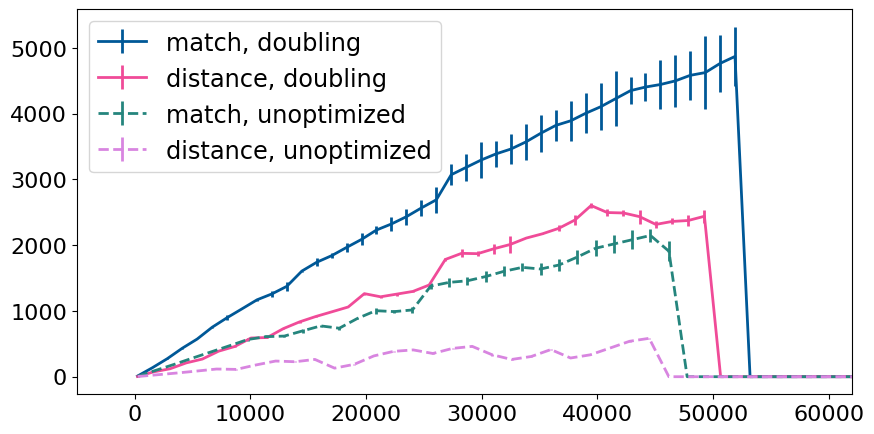

In [16]:
%matplotlib inline

dist_querylen_stats = load_results("dist_querylen_stats.pickle")
match_querylen_stats = load_results("match_querylen_stats.pickle")

fig, ax = plt.subplots()
fig.set_size_inches(10, 5)

colors =  [["#005897", "#f04b98"], ["#25857d", "#d885e0",]]
for double, color_row in zip((True, False), colors):
    for (querylen_stats, name), color in zip(zip((match_querylen_stats, dist_querylen_stats), ("match", "distance")), color_row):
        x_ls, y_ls, e_ls = coords_from_stats(querylen_stats[int(double)])
        ax.errorbar(x=x_ls, y=y_ls, yerr=[e_ls, e_ls], linewidth=2, linestyle="solid" if double else "dashed", color=color, label=f"{name}, {"doubling" if double else "unoptimized"}")
ax.set_xlim(left=-5000, right=62000)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize="xx-large")
fig.savefig(Path(RESULTS_DIR, "querylen_chain.pdf"), bbox_inches='tight')

In [17]:
# initial instance set
zlib_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.ZLIB_DEFAULT_HASH
)

coll_querylen_stats = [[] for _ in range(4)]
for max_len, opt in tqdm(list(product(test_lengths_querylen_coll, (0,)))):
    coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=zlib_inst_set_double,
                auto_expand=True,
                optimize_expand=opt,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    coll_querylen_stats[opt].append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=coll_slow_model, compress=ZlibMiniCompressor(6).compress
                ),
                n=NUM_EVALS,
                salt=f"querylen[coll,{opt},{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(coll_querylen_stats, "coll_querylen_stats.pickle")

  0%|          | 0/10 [00:00<?, ?it/s]

{'n': 1000, 'query': {'min': 1082, 'max': 1082, 'mean': 1082, 'stdev': 0.0}, 'comp_diff': {'min': 108, 'max': 118, 'mean': 112.751, 'stdev': 1.4453678037399644}, 'ratio': {'min': 0.09981515711645102, 'max': 0.10905730129390019, 'mean': 0.10420609981515712, 'stdev': 0.0013358297631607808}}
{'n': 1000, 'query': {'min': 1082, 'max': 1082, 'mean': 1082, 'stdev': 0.0}, 'comp_diff': {'min': -1, 'max': 117, 'mean': 112.725, 'stdev': 3.8699291145124803}, 'ratio': {'min': -0.0009242144177449168, 'max': 0.10813308687615526, 'mean': 0.10418207024029574, 'stdev': 0.003576644283283254}}
{'n': 1000, 'query': {'min': 3662, 'max': 3662, 'mean': 3662, 'stdev': 0.0}, 'comp_diff': {'min': 1, 'max': 620, 'mean': 612.324, 'stdev': 19.465660428969162}, 'ratio': {'min': 0.00027307482250136535, 'max': 0.16930638995084654, 'mean': 0.16721026761332605, 'stdev': 0.005315581766512606}}
{'n': 1000, 'query': {'min': 10370, 'max': 10370, 'mean': 10370, 'stdev': 0.0}, 'comp_diff': {'min': 1761, 'max': 1770, 'mean': 1

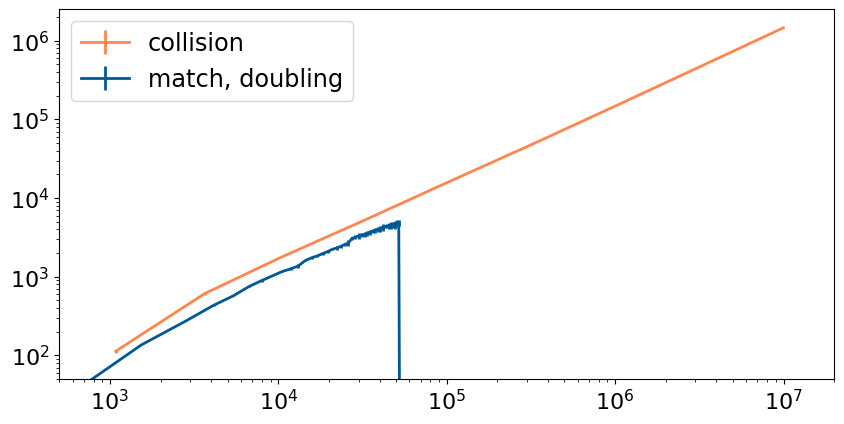

In [18]:
%matplotlib inline

coll_querylen_stats = load_results("coll_querylen_stats.pickle")
match_querylen_stats = load_results("match_querylen_stats.pickle")
for stats in coll_querylen_stats[0]:
    print(stats)

fig, ax = plt.subplots()
fig.set_size_inches(10, 4.8)

x0_ls, y0_ls, e0_ls = coords_from_stats(coll_querylen_stats[0])
x1_ls, y1_ls, e1_ls = coords_from_stats(match_querylen_stats[1])
#x2_ls, y2_ls, e2_ls = coords_from_stats(coll_querylen_stats[2])

#ax.errorbar(x=x2_ls, y=y2_ls, yerr=[e2_ls, e2_ls], linewidth=2, color="#276e9d", label="collision, optimized")
ax.errorbar(x=x0_ls, y=y0_ls, yerr=[e0_ls, e0_ls], linewidth=2, color="#ff874f", label="collision")
ax.errorbar(x=x1_ls, y=y1_ls, yerr=[e1_ls, e1_ls], linewidth=2, color="#005897", label="match, doubling")

ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(500, 2e7)
ax.set_ylim(50, 2.5e6)
ax.legend(fontsize="xx-large")
fig.savefig(Path(RESULTS_DIR, "querylen_coll.pdf"), bbox_inches='tight')

### deflate_fast

In [19]:
fast_dist_querylen_stats = [[], []]
for double, length in tqdm(list(product((True, False), test_lengths_querylen))):
    model_dist = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[3],
            filler=filler.SimpleFiller(b"-" * 100),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            DistanceChainAmplify(length=length, k=5, double=double),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    stats = report_ampl_expt_stats(
        *evaluate(
            experiment=amplify_expt_closure(
                model=model_dist, compress=ZlibMiniCompressor(3).compress
            ),
            n=NUM_EVALS,
            salt=f"querylen[fast,dist,{double},{length}]".encode(),
        )
    )
    fast_dist_querylen_stats[int(double)].append(stats)
save_results(fast_dist_querylen_stats, "fast_dist_querylen_stats.pickle")

  0%|          | 0/108 [00:00<?, ?it/s]

In [20]:
fast_match_querylen_stats = [[], []]
for double, length in tqdm(list(product((True, False), test_lengths_querylen))):
    model_match = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[3],
            filler=filler.SimpleFiller(b"-" * 100),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            MatchChainAutomatedAmplify(length=length, k=6, k_prime=None,double=double),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    stats = report_ampl_expt_stats(
        *evaluate(
            experiment=amplify_expt_closure(
                model=model_match, compress=ZlibMiniCompressor(3).compress
            ),
            n=NUM_EVALS,
            salt=f"querylen[fast,match,{double},{length}]".encode(),
        )
    )
    fast_match_querylen_stats[int(double)].append(stats)
save_results(fast_match_querylen_stats, "fast_match_querylen_stats.pickle")

  0%|          | 0/108 [00:00<?, ?it/s]

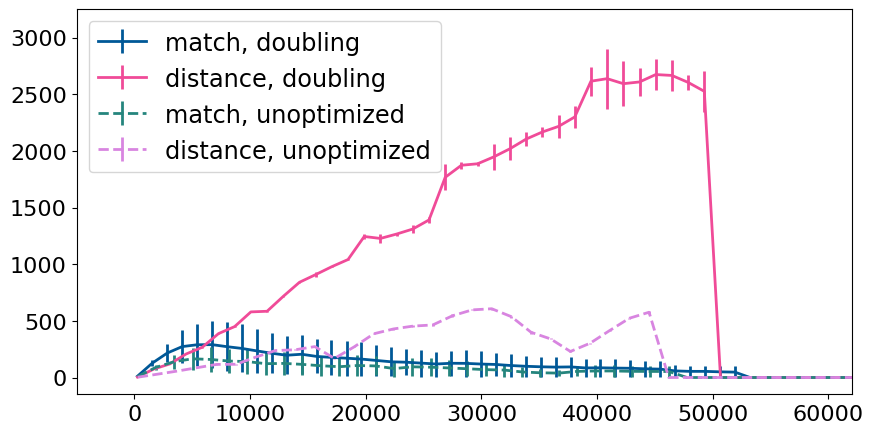

In [21]:
%matplotlib inline

fast_dist_querylen_stats = load_results("fast_dist_querylen_stats.pickle")
fast_match_querylen_stats = load_results("fast_match_querylen_stats.pickle")

fig, ax = plt.subplots()
fig.set_size_inches(10, 5)

colors =  [["#005897", "#f04b98"], ["#25857d", "#d885e0",]]
for double, color_row in zip((True, False), colors):
    for (querylen_stats, name), color in zip(zip((fast_match_querylen_stats,fast_dist_querylen_stats), ("match", "distance")), color_row):
        x_ls, y_ls, e_ls = coords_from_stats(querylen_stats[int(double)])
        ax.errorbar(x=x_ls, y=y_ls, yerr=[e_ls, e_ls], linewidth=2, linestyle="solid" if double else "dashed", color=color, label=f"{name}, {"doubling" if double else "unoptimized"}")
ax.set_xlim(left=-5000, right=62000)
ax.set_ylim(top=3250)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(fontsize="xx-large", loc="upper left")
fig.savefig(Path(RESULTS_DIR, "fast_querylen_chain.pdf"), bbox_inches='tight')

In [22]:
# initial instance set
zlib_inst_set_single = DeflateInstanceSet(
    colls=[[b"pr1", b"qPq", b"r0q", b"Pr1"]], hash_func=params.ZLIB_DEFAULT_HASH
)

fast_coll_querylen_stats = [[] for _ in range(4)]
for max_len, opt in tqdm(list(product(test_lengths_querylen_coll, (0,)))):
    coll_fast_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_PARAMS[3],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=zlib_inst_set_single,
                auto_expand=True,
                optimize_expand=opt,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    fast_coll_querylen_stats[opt].append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=coll_fast_model, compress=ZlibMiniCompressor(3).compress
                ),
                n=NUM_EVALS,
                salt=f"querylen[fast,coll,{opt},{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(fast_coll_querylen_stats, "fast_coll_querylen_stats.pickle")

  0%|          | 0/10 [00:00<?, ?it/s]

{'n': 1000, 'query': {'min': 735, 'max': 735, 'mean': 735, 'stdev': 0.0}, 'comp_diff': {'min': 2, 'max': 162, 'mean': 156.197, 'stdev': 15.059647538504478}, 'ratio': {'min': 0.0027210884353741495, 'max': 0.22040816326530613, 'mean': 0.21251292517006803, 'stdev': 0.020489316378917658}}
{'n': 1000, 'query': {'min': 735, 'max': 735, 'mean': 735, 'stdev': 0.0}, 'comp_diff': {'min': 1, 'max': 164, 'mean': 156.813, 'stdev': 11.891233427716084}, 'ratio': {'min': 0.0013605442176870747, 'max': 0.22312925170068026, 'mean': 0.21335102040816326, 'stdev': 0.016178548881246375}}
{'n': 1000, 'query': {'min': 3315, 'max': 3315, 'mean': 3315, 'stdev': 0.0}, 'comp_diff': {'min': 10, 'max': 839, 'mean': 819.834, 'stdev': 79.26246894327089}, 'ratio': {'min': 0.0030165912518853697, 'max': 0.2530920060331825, 'mean': 0.247310407239819, 'stdev': 0.023910247041710676}}
{'n': 1000, 'query': {'min': 10023, 'max': 10023, 'mean': 10023, 'stdev': 0.0}, 'comp_diff': {'min': 12, 'max': 2359, 'mean': 2318.8, 'stdev':

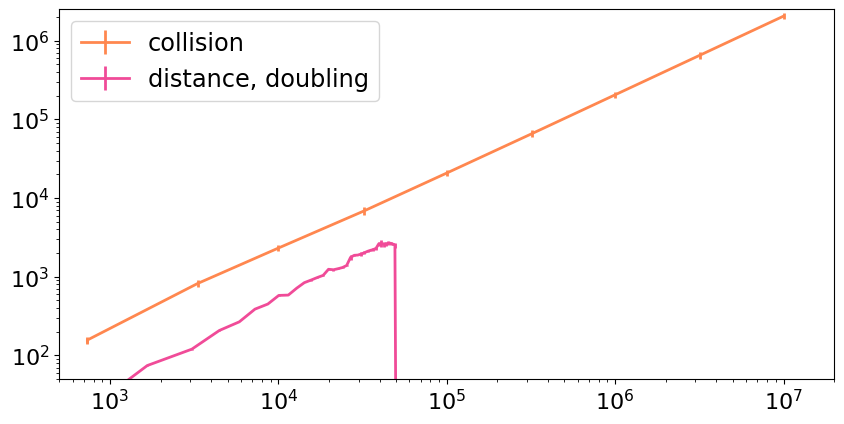

In [23]:
%matplotlib inline

fast_coll_querylen_stats = load_results("fast_coll_querylen_stats.pickle")
fast_dist_querylen_stats = load_results("fast_dist_querylen_stats.pickle")
for stats in fast_coll_querylen_stats[0]:
    print(stats)

fig, ax = plt.subplots()
fig.set_size_inches(10, 4.8)

x0_ls, y0_ls, e0_ls = coords_from_stats(fast_coll_querylen_stats[0])
x1_ls, y1_ls, e1_ls = coords_from_stats(fast_dist_querylen_stats[1])
#x2_ls, y2_ls, e2_ls = coords_from_stats(coll_querylen_stats[2])

#ax.errorbar(x=x2_ls, y=y2_ls, yerr=[e2_ls, e2_ls], linewidth=2, color="#276e9d", label="collision, optimized")
ax.errorbar(x=x0_ls, y=y0_ls, yerr=[e0_ls, e0_ls], linewidth=2, color="#ff874f", label="collision")
ax.errorbar(x=x1_ls, y=y1_ls, yerr=[e1_ls, e1_ls], linewidth=2, color="#f04b98", label="distance, doubling")

ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(500, 2e7)
ax.set_ylim(50, 2.5e6)
ax.legend(fontsize="xx-large")
fig.savefig(Path(RESULTS_DIR, "fast_querylen_coll.pdf"), bbox_inches='tight')

## Noise

In [24]:
NOISE_LEVEL = 50
NOISE_NUM_EVALS = 10 * NUM_EVALS
NOISE_MAX_QUERY_LEN = 1024
NOISE_X_MIN = -120
NOISE_X_MAX = 220
NOISE_Y_MAX = 610
NOISE_BIN_WIDTH = 5
NOISE_LABEL_X_SHIFT = NOISE_BIN_WIDTH + 8
NOISE_LABEL_Y = NOISE_Y_MAX * 0.85
NOISE_BINS = range(NOISE_X_MIN, NOISE_X_MAX + NOISE_BIN_WIDTH, NOISE_BIN_WIDTH)

In [25]:
def plot_hist_noise(
    query_lens: Iterable[int],
    data_right: Iterable[int],
    data_wrong: Iterable[int],
    reverse_diff: bool = False,
    kwargs: dict | None = None,
    filename: str | None = None,
):
    if kwargs is None:
        kwargs = dict()
    fig, ax = plt.subplots()
    fig.set_size_inches(10, 2)
    ax.set_xlim(left=NOISE_X_MIN, right=NOISE_X_MAX)
    ax.set_ylim(top=NOISE_Y_MAX)

    comp_diff_lens = (
        diff(data_right, data_wrong) if reverse_diff else diff(data_wrong, data_right)
    )

    ax.hist(comp_diff_lens, histtype="bar", bins=NOISE_BINS, **kwargs)

    mean_diff = mean(comp_diff_lens)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.axvline(mean_diff, linestyle="dashed", color="goldenrod", linewidth=2)
    ax.text(
        mean_diff + NOISE_LABEL_X_SHIFT,
        NOISE_LABEL_Y,
        s=f"mean={mean_diff:.2f}",
        fontsize="xx-large",
    )

    if filename is not None:
        fig.savefig(Path(RESULTS_DIR, filename), bbox_inches="tight")

    return fig, ax

### baseline

In [26]:
vanilla_model = CRIMEChainModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        dict_1=dictionary.NullDictionary(),
        filler=filler.SimpleFiller(),
        dict_2=dictionary.NullDictionary(),
    ),
    gadgets=[
        PlaceholderGadget("<match_placeholder>"),
    ],
    placeholder=0,
    match_builder=deflate_match_builder_default,
)

vanilla_model(b"secret=1", rng=None, recompile=True)

b'secret=1'

In [27]:
results_noise_vanilla = evaluate(
    experiment=amplify_expt_closure(
        model=vanilla_model,
        compress=ZlibMiniCompressor(6).compress,
        noise_size=NOISE_LEVEL,
    ),
    n=NOISE_NUM_EVALS,
    salt=b"noise_vanilla",
)

save_results(results_noise_vanilla, f"noise_{NOISE_LEVEL}_vanilla.pickle")

{'n': 10000, 'query': {'min': 9, 'max': 9, 'mean': 9, 'stdev': 0.0}, 'comp_diff': {'min': -99, 'max': 99, 'mean': 0.9027, 'stdev': 38.78382460788417}, 'ratio': {'min': -11.0, 'max': 11.0, 'mean': 0.1003, 'stdev': 4.309313845320463}}


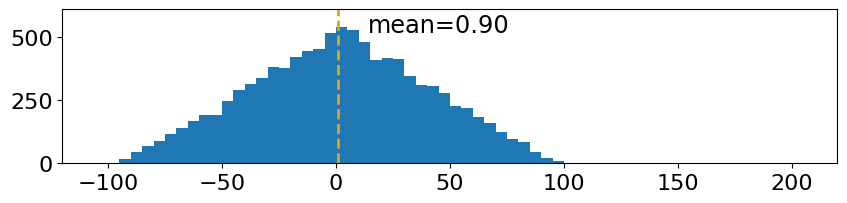

In [28]:
%matplotlib inline
results_noise_vanilla = load_results(f"noise_{NOISE_LEVEL}_vanilla.pickle")
print(report_ampl_expt_stats(*results_noise_vanilla))
fig, ax = plot_hist_noise(*results_noise_vanilla, filename=f"noise_{NOISE_LEVEL}_vanilla.pdf")

### Distance

In [29]:
dist_model = CRIMEChainModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(b"-" * 100),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        DistanceChainAmplify(length=312, k=4, double=True),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)

results_noise_dist = evaluate(
    experiment=amplify_expt_closure(
        model=dist_model,
        compress=ZlibMiniCompressor(6).compress,
        noise_size=NOISE_LEVEL,
    ),
    n=NOISE_NUM_EVALS,
    salt=b"noise_dist",
)

save_results(results_noise_dist, f"noise_{NOISE_LEVEL}_dist.pickle")

{'n': 10000, 'query': {'min': 1013, 'max': 1023, 'mean': 1022.9985, 'stdev': 0.11179892620231198}, 'comp_diff': {'min': -60, 'max': 136, 'mean': 37.1403, 'stdev': 38.13026367087908}, 'ratio': {'min': -0.05865102639296188, 'max': 0.13294232649071358, 'mean': 0.03630527952891053, 'stdev': 0.03727298655688617}}


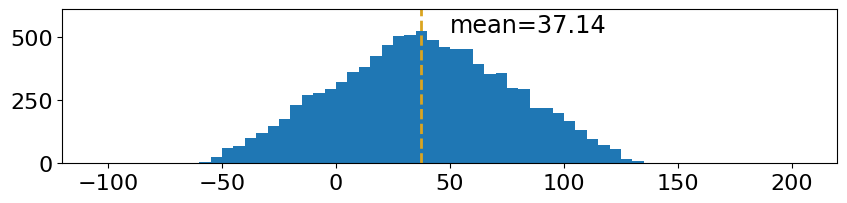

In [30]:
%matplotlib inline
results_noise_dist = load_results(f"noise_{NOISE_LEVEL}_dist.pickle")
print(report_ampl_expt_stats(*results_noise_dist))
assert(max(results_noise_dist[0]) <= NOISE_MAX_QUERY_LEN)
fig, ax = plot_hist_noise(*results_noise_dist, filename=f"noise_{NOISE_LEVEL}_dist.pdf")

### Match

In [31]:
match_model = CRIMEChainModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(b"-" * 100),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainLazyAmplify(length=345, k=5, double=True),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)

results_noise_match = evaluate(
    experiment=amplify_expt_closure(
        model=match_model,
        compress=ZlibMiniCompressor(6).compress,
        noise_size=NOISE_LEVEL,
    ),
    n=NOISE_NUM_EVALS,
    salt=b"noise_match",
)

save_results(results_noise_match, f"noise_{NOISE_LEVEL}_match.pickle")

{'n': 10000, 'query': {'min': 1016, 'max': 1021, 'mean': 1020.999, 'stdev': 0.07070714214274962}, 'comp_diff': {'min': -42, 'max': 200, 'mean': 101.5804, 'stdev': 38.54210016577352}, 'ratio': {'min': -0.04113614103819784, 'max': 0.1958863858961802, 'mean': 0.09949118887226512, 'stdev': 0.037749379130487946}}


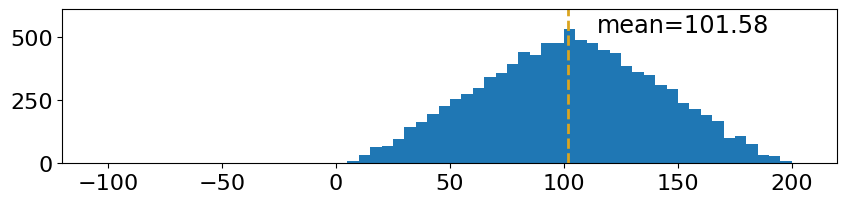

In [32]:
%matplotlib inline
results_noise_match = load_results(f"noise_{NOISE_LEVEL}_match.pickle")
print(report_ampl_expt_stats(*results_noise_match))
assert(max(results_noise_match[0]) <= NOISE_MAX_QUERY_LEN)
fig, ax = plot_hist_noise(*results_noise_match, filename=f"noise_{NOISE_LEVEL}_match.pdf")

### Collision

In [33]:
zlib_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.ZLIB_DEFAULT_HASH
)

coll_model = CRIMEChainModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        CollisionAmplify(
            max_len=460,
            instance=zlib_inst_set_double,
            auto_expand=True,
            optimize_expand=0,
            nop_gadget=None,
            aligned=False,
        ),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)

results_noise_coll = evaluate(
    experiment=amplify_expt_closure(
        model=coll_model,
        compress=ZlibMiniCompressor(6).compress,
        noise_size=NOISE_LEVEL,
    ),
    n=NOISE_NUM_EVALS,
    salt=b"noise_coll",
)

save_results(results_noise_coll, f"noise_{NOISE_LEVEL}_coll.pickle")

{'n': 10000, 'query': {'min': 1020, 'max': 1020, 'mean': 1020, 'stdev': 0.0}, 'comp_diff': {'min': -198, 'max': 63, 'mean': -97.7952, 'stdev': 38.57378190721079}, 'ratio': {'min': -0.19411764705882353, 'max': 0.061764705882352944, 'mean': -0.09587764705882353, 'stdev': 0.03781743324236352}}


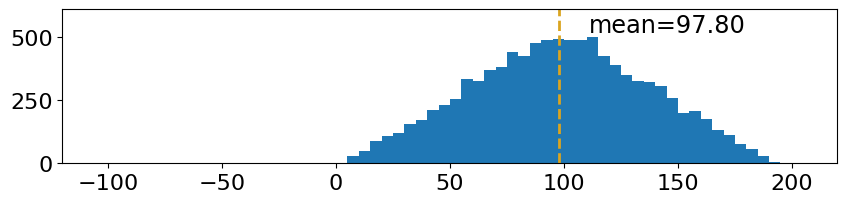

In [34]:
%matplotlib inline
results_noise_coll = load_results(f"noise_{NOISE_LEVEL}_coll.pickle")
print(report_ampl_expt_stats(*results_noise_coll))
assert(max(results_noise_coll[0]) <= NOISE_MAX_QUERY_LEN)
fig, ax = plot_hist_noise(*results_noise_coll, reverse_diff=True, filename=f"noise_{NOISE_LEVEL}_coll.pdf")

### CRIME cascade

In [35]:
NUM_PLACEHOLDERS = 8
CASCADE_NOISE_LEVEL = 50

In [36]:
# `[k1 filler bytes][prefix][secret][k2 filler bytes][query][k3 filler bytes][optional noise]`
def amplify_cascade_expt_closure(
    model: CRIMECascadeModel,
    compress: Callable[[Any], bytes],
    which_slot: int,
    filler_sizes: tuple[int, int, int] = (500, 500, 500),
    filler_charset: bytes = utils.ASCII_PRINTABLE_BYTES,
    prefix_size: int = 8,
    prefix_charset: bytes = utils.ALPHANUMERIC_BYTES,
    secret_size: int = 1,
    secret_charset: bytes = utils.ALPHANUMERIC_BYTES,
    noise_size: int = 0,
    noise_charset: bytes = utils.ALL_BYTES,
    pad_size: int = 0,
) -> Callable[[Random, Random], tuple[int, ...] | None]:
    num_slots = len(model.placeholders)
    assert 0 <= which_slot < num_slots, (which_slot, num_slots)

    def amplify_expt(
        attack_rng: Random, eval_rng: Random
    ) -> list[tuple[int, int, int]] | None:
        fillers = [
            RandBytes(filler_charset, eval_rng).randbytes(filler_sizes[i])
            for i in range(3)
        ]
        prefix = RandBytes(prefix_charset, eval_rng).randbytes(prefix_size)
        secret = RandBytes(secret_charset, eval_rng).randbytes(secret_size)
        wrong_guesses: list[bytes] = []
        seen = {secret}
        while len(wrong_guesses) < num_slots:
            guess_wrong = RandBytes(secret_charset, eval_rng).randbytes(secret_size)
            if guess_wrong not in seen:
                wrong_guesses.append(guess_wrong)
                seen.add(guess_wrong)
        template = [
            fillers[0],
            prefix,
            Placeholder.SECRET,
            Placeholder.NOISE,
            fillers[1],
            Placeholder.QUERY,
            fillers[2],
        ]
        oracle = TestCompressionLengthOracle(
            template=template,
            compress=compress,
            secret=secret,
            noise_lens=[unif_noise_len_closure(0, noise_size)],
            noise_charset=noise_charset,
            pad_len=unif_pad_len_closure(0, pad_size),
            rng=eval_rng,
        )

        updates_wrong = [[prefix + guess] for guess in wrong_guesses]
        updates_right = [[prefix + guess] for guess in wrong_guesses]
        updates_right[which_slot] = [prefix + secret]

        model.flush()  # just in case
        if eval_rng.choice([True, False]):
            query_right = model(updates_right, attack_rng, recompile=True)
            query_wrong = model(updates_wrong, attack_rng, recompile=False)
        else:
            query_wrong = model(updates_wrong, attack_rng, recompile=True)
            query_right = model(updates_right, attack_rng, recompile=False)
        if query_right is None or query_wrong is None:
            return None

        len_right = oracle(query_right)
        len_wrong = oracle(query_wrong)

        return max(len(query_right), len(query_wrong)), len_right, len_wrong

    return amplify_expt

In [37]:
zlib_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.ZLIB_DEFAULT_HASH
)

cascade_coll_model = CRIMECascadeModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder 0>"),
        CollisionAmplify(
            max_len=1200,
            instance=zlib_inst_set_double,
            auto_expand=True,
            no_dict=False,
            nop_gadget=None,
        ),
    ],
    placeholder=[2 * i + 1 for i in range(NUM_PLACEHOLDERS)],
    match_builder=deflate_match_builder_default,
)

for i in range(1, NUM_PLACEHOLDERS):
    cascade_coll_model.gadgets += [
        PlaceholderGadget(f"<match_placeholder {i}>"),
        CollisionAmplify(
            max_len=1200,
            instance=zlib_inst_set_double,
            auto_expand=True,
            no_dict=True,
            nop_gadget=None,
            mirroring_gadget=cascade_coll_model.gadgets[2],
        ),
    ]

In [38]:
results_cascade_coll = []
for which_slot in tqdm(range(NUM_PLACEHOLDERS)):
    results_cascade_coll.append(
        evaluate(
            experiment=amplify_cascade_expt_closure(
                model=cascade_coll_model,
                which_slot=which_slot,
                compress=ZlibMiniCompressor(6).compress,
                noise_size=CASCADE_NOISE_LEVEL,
            ),
            n=NUM_EVALS,
            salt=f"cascade[coll,{CASCADE_NOISE_LEVEL},{which_slot}]".encode(),
        )
    )

save_results(results_cascade_coll, f"cascade_coll_{CASCADE_NOISE_LEVEL}.pickle")

  0%|          | 0/8 [00:00<?, ?it/s]

5 -687
max_query_len: 9221


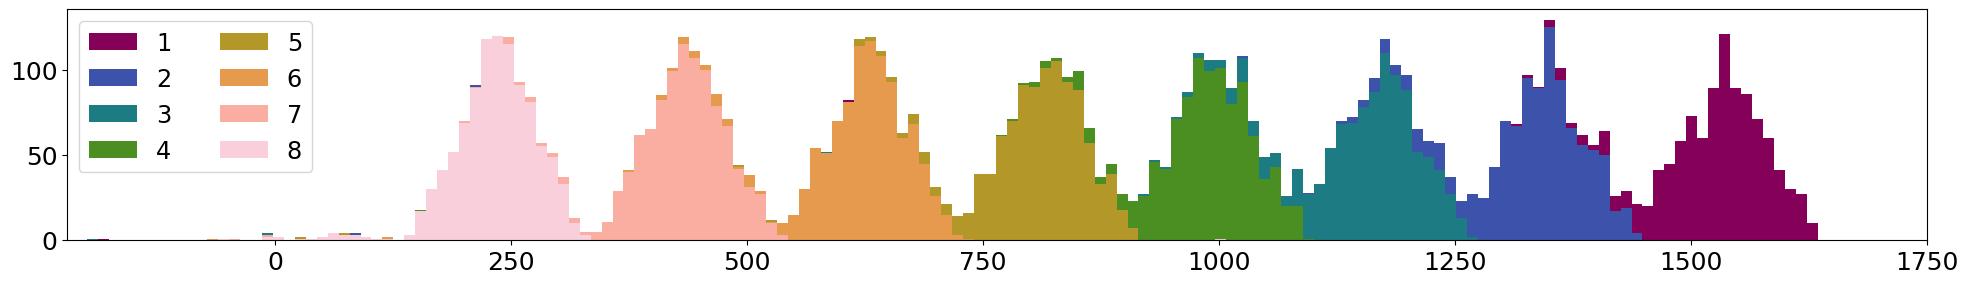

In [39]:
%matplotlib inline

results_cascade_coll = load_results(f"cascade_coll_{CASCADE_NOISE_LEVEL}.pickle")


data_cascade_coll = []
max_query_len = 0
for which_slot, results in enumerate(results_cascade_coll):
    max_query_len = max(max_query_len, max(results[0]))
    data_cascade_coll.append(diff(results[1], results[2]))
    for data in data_cascade_coll[-1]:
        if data < -220:
            print(which_slot, data)
    #data_cascade_coll.append(results[1])

print("max_query_len:", max_query_len)

fig, ax = plt.subplots()
fig.set_size_inches(24, 3)

labels = [f"{i}" for i in range(1, NUM_PLACEHOLDERS + 1)]
ax.hist(data_cascade_coll[::-1],
        histtype="bar",
        stacked=True,
        bins=200,
        label=labels[::-1],
        color=list(reversed(["#850059", "#3D53AB", "#1D7C83", "#4B8F23", "#B39829", "#e69a4e", "#faaea1", "#f9cfdb"]))

    )

ax.set_xlim(left=-220)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper left', fontsize="xx-large", ncol=2)
ax.tick_params(axis='both', which='major', labelsize=18)
fig.savefig(Path(RESULTS_DIR, f"cascade_coll_{CASCADE_NOISE_LEVEL}.pdf"), bbox_inches='tight')
fig.savefig(Path(RESULTS_DIR, f"cascade_coll_{CASCADE_NOISE_LEVEL}.png"), bbox_inches='tight')

## Compressor implementations

In [40]:
test_lengths_impl_coll = [
    1200,  # zlib-ng requires longer queries
    10000,
    100000,
    1_000_000,
    10_000_000,
]

### gzip

In [41]:
gzip_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.GZIP_DEFAULT_HASH
)
gzip_inst_set_double.is_consistent_deflate_slow_instance()

True

In [42]:
gzip_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    gzip_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.GZIP_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=gzip_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    gzip_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=gzip_coll_slow_model, compress=GZipCompressor(6).compress
                ),
                n=NUM_EVALS,
                salt=f"gzip[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(gzip_coll_stats, "gzip_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [43]:
gzip_coll_stats = load_results("gzip_coll_stats.pickle")
for stats in gzip_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1598, 'max': 1598, 'mean': 1598, 'stdev': 0.0}, 'comp_diff': {'min': 215, 'max': 224, 'mean': 219.128, 'stdev': 1.4966147987561313}, 'ratio': {'min': 0.13454317897371715, 'max': 0.14017521902377972, 'mean': 0.13712640801001252, 'stdev': 0.0009365549429012129}}
{'n': 1000, 'query': {'min': 10370, 'max': 10370, 'mean': 10370, 'stdev': 0.0}, 'comp_diff': {'min': 1760, 'max': 1771, 'mean': 1765.345, 'stdev': 1.6801183880303785}, 'ratio': {'min': 0.16972034715525555, 'max': 0.1707810993249759, 'mean': 0.1702357762777242, 'stdev': 0.0001620172023172944}}
{'n': 1000, 'query': {'min': 100154, 'max': 100154, 'mean': 100154, 'stdev': 0.0}, 'comp_diff': {'min': 15684, 'max': 15698, 'mean': 15690.818, 'stdev': 2.328582894873682}, 'ratio': {'min': 0.1565988377898037, 'max': 0.15673862252131718, 'mean': 0.15666691295405077, 'stdev': 2.325002391190944e-05}}
{'n': 1000, 'query': {'min': 1000058, 'max': 1000058, 'mean': 1000058, 'stdev': 0.0}, 'comp_diff': {'min': 0, 'max':

### zlib-ng

In [44]:
ng_inst_set_double = DeflateInstanceSet(
    colls=[[b"O2j49", b"WRF06"], [b"ONk9s", b"WfusA"], [b"OXZC3", b"WnG5p"]],
    hash_func=params.ZLIB_NG_HASH,
)

ng_inst_set_double.is_deflate_slow_instance(), ng_inst_set_double.is_consistent_deflate_slow_instance()

(True, False)

In [45]:
ng_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    ng_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_NG_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=ng_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    ng_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=ng_coll_slow_model,
                    compress=ZlibNGCompressor(6).compress,
                ),
                n=NUM_EVALS,
                salt=f"ng[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(ng_coll_stats, "ng_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [46]:
ng_coll_stats = load_results("ng_coll_stats.pickle")
for stats in ng_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 2118, 'max': 2119, 'mean': 2118.947, 'stdev': 0.22414558046332575}, 'comp_diff': {'min': 173, 'max': 237, 'mean': 231.18, 'stdev': 2.6688429557998954}, 'ratio': {'min': 0.08164228409627183, 'max': 0.11184521000471921, 'mean': 0.10910132703749208, 'stdev': 0.001256595259509511}}
{'n': 1000, 'query': {'min': 10374, 'max': 10375, 'mean': 10374.945, 'stdev': 0.22809433799861634}, 'comp_diff': {'min': 1795, 'max': 1881, 'mean': 1849.362, 'stdev': 14.07931756809197}, 'ratio': {'min': 0.1730287256603046, 'max': 0.1813012048192771, 'mean': 0.1782526789448134, 'stdev': 0.0013538278949955568}}
{'n': 1000, 'query': {'min': 100158, 'max': 100159, 'mean': 100158.932, 'stdev': 0.2518718710762268}, 'comp_diff': {'min': 17, 'max': 17755, 'mean': 17392.998, 'stdev': 564.9818231204049}, 'ratio': {'min': 0.00016973012909473936, 'max': 0.17726814365159396, 'mean': 0.17365398550231528, 'stdev': 0.00564076675903172}}
{'n': 1000, 'query': {'min': 1000062, 'max': 1000063, 'mean': 

### cloudflare-zlib

In [47]:
cf_inst_set_double = DeflateInstanceSet(
    colls=[[b"6NHFe", b"P8XNM", b"Sp73N", b"VetdK", b"svldT"]],
    hash_func=params.ZLIB_CLOUDFLARE_DEFAULT_HASH,
)
cf_inst_set_double.is_consistent_deflate_slow_instance()

True

In [48]:
cf_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    cf_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_CLOUDFLARE_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=cf_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    cf_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=cf_coll_slow_model,
                    compress=ZlibCloudflareCompressor(6).compress,
                ),
                n=NUM_EVALS,
                salt=f"cf[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(cf_coll_stats, "cf_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [49]:
cf_coll_stats = load_results("cf_coll_stats.pickle")
for stats in cf_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1601, 'max': 1601, 'mean': 1601, 'stdev': 0.0}, 'comp_diff': {'min': 33, 'max': 223, 'mean': 218.3, 'stdev': 7.539153721661261}, 'ratio': {'min': 0.02061211742660837, 'max': 0.13928794503435352, 'mean': 0.1363522798251093, 'stdev': 0.004709027933579801}}
{'n': 1000, 'query': {'min': 10373, 'max': 10373, 'mean': 10373, 'stdev': 0.0}, 'comp_diff': {'min': 1751, 'max': 1765, 'mean': 1758.332, 'stdev': 1.9523287601189476}, 'ratio': {'min': 0.16880362479514124, 'max': 0.17015328256049359, 'mean': 0.16951045984768148, 'stdev': 0.00018821254797252255}}
{'n': 1000, 'query': {'min': 100157, 'max': 100157, 'mean': 100157, 'stdev': 0.0}, 'comp_diff': {'min': 15545, 'max': 15696, 'mean': 15590.287, 'stdev': 5.1646204414559165}, 'ratio': {'min': 0.15520632606807314, 'max': 0.15671395908423774, 'mean': 0.15565848617670258, 'stdev': 5.156524697680521e-05}}
{'n': 1000, 'query': {'min': 1000061, 'max': 1000061, 'mean': 1000061, 'stdev': 0.0}, 'comp_diff': {'min': 147839, 'm

### chromium-zlib

In [50]:
cr_inst_set_double = DeflateInstanceSet(
    colls=[[b"0DqH8", b"1roIf", b"3qAKe"]],
    hash_func=params.ZLIB_CHROMIUM_DEFAULT_HASH,
)
cr_inst_set_double.is_consistent_deflate_slow_instance()

True

In [51]:
cr_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    cr_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.ZLIB_CHROMIUM_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=cr_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    cr_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=cr_coll_slow_model,
                    compress=ZlibChromiumCompressor(6).compress,
                ),
                n=NUM_EVALS,
                salt=f"cr[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(cr_coll_stats, "cr_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [52]:
cr_coll_stats = load_results("cr_coll_stats.pickle")
for stats in cr_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1601, 'max': 1601, 'mean': 1601, 'stdev': 0.0}, 'comp_diff': {'min': 197, 'max': 207, 'mean': 201.681, 'stdev': 1.5341422986778614}, 'ratio': {'min': 0.12304809494066209, 'max': 0.1292941911305434, 'mean': 0.12597189256714553, 'stdev': 0.0009582400366507573}}
{'n': 1000, 'query': {'min': 10373, 'max': 10373, 'mean': 10373, 'stdev': 0.0}, 'comp_diff': {'min': 12, 'max': 1638, 'mean': 1629.344, 'stdev': 51.24392260164715}, 'ratio': {'min': 0.001156849513159163, 'max': 0.15790995854622578, 'mean': 0.15707548443073363, 'stdev': 0.004940125576173446}}
{'n': 1000, 'query': {'min': 100157, 'max': 100157, 'mean': 100157, 'stdev': 0.0}, 'comp_diff': {'min': 72, 'max': 14435, 'mean': 14371.487, 'stdev': 452.6544088428222}, 'ratio': {'min': 0.0007188713719460448, 'max': 0.1441237257505716, 'mean': 0.1434895913415937, 'stdev': 0.004519448554198131}}
{'n': 1000, 'query': {'min': 1000061, 'max': 1000061, 'mean': 1000061, 'stdev': 0.0}, 'comp_diff': {'min': 81, 'max': 142

### zlib-go

In [53]:
go_inst_set_double = DeflateInstanceSet(
    colls=[[b"w7jNC", b"PN20C", b"68TVC"]], hash_func=params.ZLIB_GO_HASH
)

In [54]:
go_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    go_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.GO_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=go_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    go_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=go_coll_slow_model, compress=GoFlateCompressor(6).compress
                ),
                n=NUM_EVALS,
                salt=f"go[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(go_coll_stats, "go_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [55]:
go_coll_stats = load_results("go_coll_stats.pickle")
for stats in go_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1601, 'max': 1601, 'mean': 1601, 'stdev': 0.0}, 'comp_diff': {'min': 198, 'max': 207, 'mean': 202.229, 'stdev': 1.5990985323350517}, 'ratio': {'min': 0.12367270455965022, 'max': 0.1292941911305434, 'mean': 0.12631417863835104, 'stdev': 0.0009988123250062768}}
{'n': 1000, 'query': {'min': 10373, 'max': 10373, 'mean': 10373, 'stdev': 0.0}, 'comp_diff': {'min': 1625, 'max': 1639, 'mean': 1630.737, 'stdev': 2.2146637974500183}, 'ratio': {'min': 0.15665670490697, 'max': 0.15800636267232238, 'mean': 0.1572097753783862, 'stdev': 0.00021350272799094115}}
{'n': 1000, 'query': {'min': 100157, 'max': 100157, 'mean': 100157, 'stdev': 0.0}, 'comp_diff': {'min': 14286, 'max': 14437, 'mean': 14385.908, 'stdev': 5.643880702972857}, 'ratio': {'min': 0.1426360613836277, 'max': 0.14414369439979233, 'mean': 0.1436335752867997, 'stdev': 5.635033700063752e-05}}
{'n': 1000, 'query': {'min': 1000061, 'max': 1000061, 'mean': 1000061, 'stdev': 0.0}, 'comp_diff': {'min': 9, 'max': 14

### flate2-rust

In [56]:
rust_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.MINIZ_DEFAULT_HASH
)

In [57]:
rust_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    rust_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.MINIZ_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 10),
            PlaceholderGadget("<match_placeholder>"),
            CollisionAmplify(
                max_len=max_len,
                instance=rust_inst_set_double,
                auto_expand=True,
                optimize_expand=0,
                nop_gadget=None,
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    rust_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=rust_coll_slow_model, compress=RustFlate2Compressor(6).compress
                ),
                n=NUM_EVALS,
                salt=f"rust[coll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(rust_coll_stats, "rust_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [58]:
rust_coll_stats = load_results("rust_coll_stats.pickle")
for stats in rust_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1598, 'max': 1598, 'mean': 1598, 'stdev': 0.0}, 'comp_diff': {'min': 215, 'max': 224, 'mean': 219.215, 'stdev': 1.445982664441682}, 'ratio': {'min': 0.13454317897371715, 'max': 0.14017521902377972, 'mean': 0.1371808510638298, 'stdev': 0.0009048702530924212}}
{'n': 1000, 'query': {'min': 10370, 'max': 10370, 'mean': 10370, 'stdev': 0.0}, 'comp_diff': {'min': 1759, 'max': 1769, 'mean': 1765.109, 'stdev': 1.553554805126788}, 'ratio': {'min': 0.16962391513982641, 'max': 0.17058823529411765, 'mean': 0.17021301832208294, 'stdev': 0.0001498124209379699}}
{'n': 1000, 'query': {'min': 100154, 'max': 100154, 'mean': 100154, 'stdev': 0.0}, 'comp_diff': {'min': 10313, 'max': 10327, 'mean': 10321.305, 'stdev': 2.3433878181953722}, 'ratio': {'min': 0.10297142400702917, 'max': 0.10311120873854264, 'mean': 0.1030543463066877, 'stdev': 2.339784549988329e-05}}
{'n': 1000, 'query': {'min': 1000058, 'max': 1000058, 'mean': 1000058, 'stdev': 0.0}, 'comp_diff': {'min': -25369, '

In [59]:
rust_alt_coll_stats = []

for max_len in tqdm(test_lengths_impl_coll):
    rust_alt_coll_slow_model = CRIMEChainModel(
        machine=automata.DeflateAutomaton(
            charset=utils.ALPHANUMERIC_BYTES,
            params=params.MINIZ_PARAMS[6],
            filler=filler.SimpleFiller(),
        ),
        gadgets=[
            DefaultAlign(b"@", 9), # adjust align
            PlaceholderGadget("<match_placeholder>"),
            AltCollisionAmplify(
                max_len=max_len,
                instance=rust_inst_set_double,
                l=12,
                auto_expand=True,
                nop_gadget=None,
                relax_align=True
            ),
        ],
        placeholder=1,
        match_builder=deflate_match_builder_default,
    )

    rust_alt_coll_stats.append(
        report_ampl_expt_stats(
            *evaluate(
                experiment=amplify_expt_closure(
                    model=rust_alt_coll_slow_model, compress=RustFlate2Compressor(6).compress
                ),
                n=NUM_EVALS,
                salt=f"rust[altcoll,{max_len}]".encode(),
            ),
            reverse_diff=True,
        )
    )

save_results(rust_alt_coll_stats, "rust_alt_coll_stats.pickle")

  0%|          | 0/5 [00:00<?, ?it/s]

In [60]:
rust_alt_coll_stats = load_results("rust_alt_coll_stats.pickle")
for stats in rust_alt_coll_stats:
    print(stats)

{'n': 1000, 'query': {'min': 1781, 'max': 1781, 'mean': 1781, 'stdev': 0.0}, 'comp_diff': {'min': 104, 'max': 113, 'mean': 108.41, 'stdev': 1.3739678991111066}, 'ratio': {'min': 0.058394160583941604, 'max': 0.06344750140370578, 'mean': 0.06087029758562605, 'stdev': 0.0007714586744026421}}
{'n': 1000, 'query': {'min': 10553, 'max': 10553, 'mean': 10553, 'stdev': 0.0}, 'comp_diff': {'min': 354, 'max': 1093, 'mean': 1083.421, 'stdev': 24.893924288196636}, 'ratio': {'min': 0.03354496351748318, 'max': 0.10357244385482801, 'mean': 0.10266473988439306, 'stdev': 0.002358942887159731}}
{'n': 1000, 'query': {'min': 100853, 'max': 100853, 'mean': 100853, 'stdev': 0.0}, 'comp_diff': {'min': 0, 'max': 9981, 'mean': 9929.328, 'stdev': 653.360062896247}, 'ratio': {'min': 0.0, 'max': 0.09896582154224465, 'mean': 0.09845347188482247, 'stdev': 0.006478340385474374}}
{'n': 1000, 'query': {'min': 1000757, 'max': 1000757, 'mean': 1000757, 'stdev': 0.0}, 'comp_diff': {'min': 118, 'max': 99285, 'mean': 94897

### Illustration

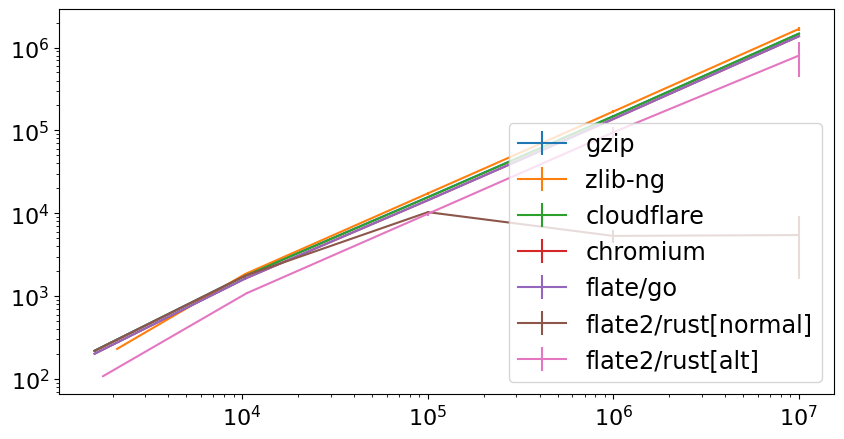

In [61]:
%matplotlib inline

fig, ax = plt.subplots()
fig.set_size_inches(10, 5)

for stats, name in ((gzip_coll_stats, "gzip"), (ng_coll_stats, "zlib-ng"), (cf_coll_stats, "cloudflare"), (cr_coll_stats, "chromium"), (go_coll_stats, "flate/go"), (rust_coll_stats, "flate2/rust[normal]"), (rust_alt_coll_stats, "flate2/rust[alt]")):
    x_ls, y_ls, e_ls = coords_from_stats(stats)
    ax.errorbar(x=x_ls, y=y_ls, yerr=[e_ls, e_ls], label=name)

ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize="xx-large")